In [90]:
import pandas as pd
df = pd.read_csv(r'/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/Logistic Regression/Obesity Classification.csv')
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


In [91]:
df.shape

(108, 6)

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     108 non-null    int64  
 1   Gender  108 non-null    str    
 2   BMI     108 non-null    float64
 3   Height  108 non-null    int64  
 4   Weight  108 non-null    int64  
 5   Label   108 non-null    str    
dtypes: float64(1), int64(3), str(2)
memory usage: 5.2 KB


In [93]:
df.describe()

,Age,BMI,Height,Weight
count,108.000000,108.000000,108.000000,108.000000
mean,46.555556,20.549074,166.574074,59.490741
std,24.720620,7.583818,27.873615,28.856233
min,11.000000,3.900000,120.000000,10.000000
25%,27.000000,16.700000,140.000000,35.000000
50%,42.500000,21.200000,175.000000,55.000000
75%,59.250000,26.100000,190.000000,85.000000
max,112.000000,37.200000,210.000000,120.000000


In [94]:
df.query("Age == 112")

,Age,Gender,BMI,Height,Weight,Label
57,112,Female,27.5,120,85,Overweight


In [95]:
df.describe(include='object')

/tmp/ipykernel_12778/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Label
count,108,108
unique,2,4
top,Male,Underweight
freq,56,47


In [96]:
df.isnull().sum()

Age       0
Gender    0
BMI       0
Height    0
Weight    0
Label     0
dtype: int64

In [97]:
print(df.duplicated().sum())

0


## EDA

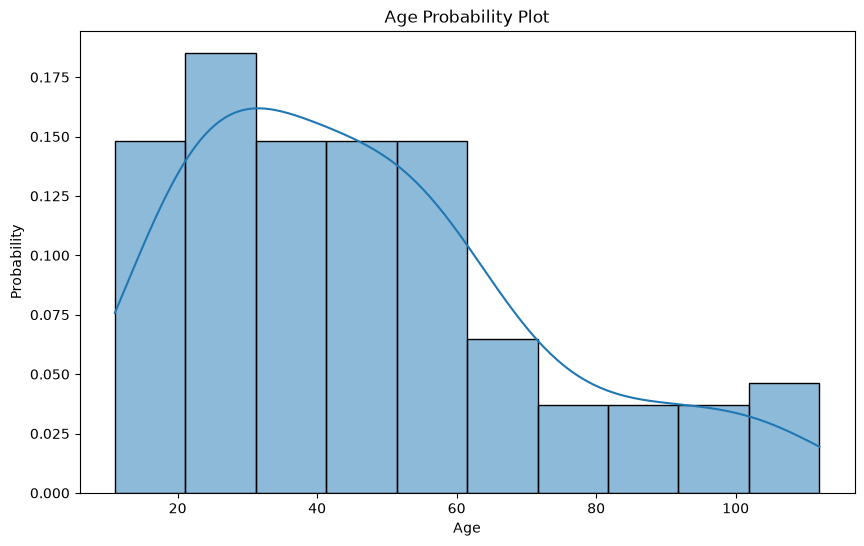

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=10, stat='probability')
plt.xlabel('Age')
plt.ylabel('Probability')
plt.title('Age Probability Plot')
plt.show()

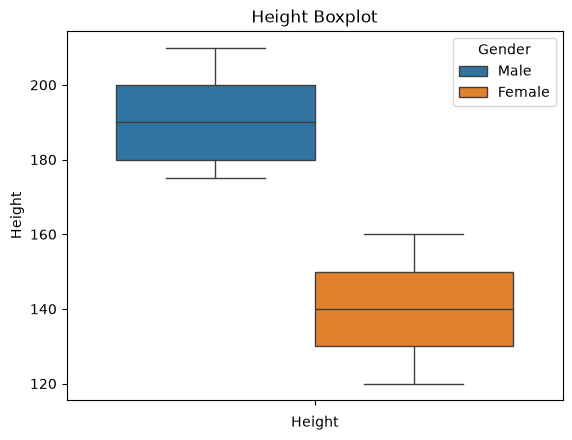

In [99]:
sns.boxplot(y='Height', data=df, hue='Gender')
plt.xlabel('Height')
plt.title('Height Boxplot')
plt.show()

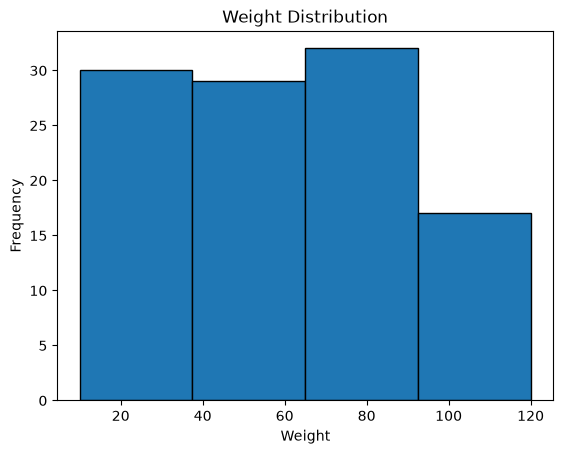

In [100]:
df['Weight'].plot(kind='hist', bins=4, edgecolor='black')
plt.xlabel('Weight')
plt.title('Weight Distribution')
plt.show()

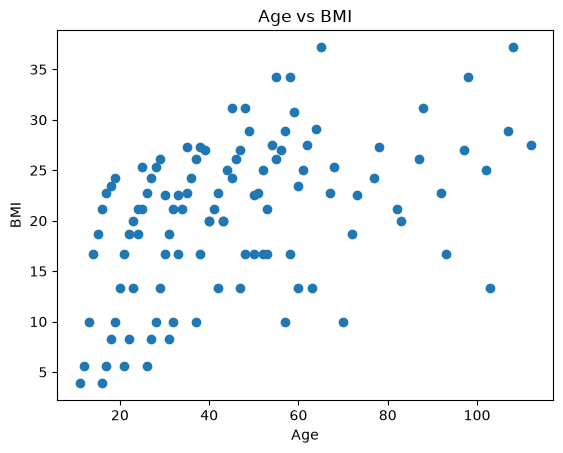

In [101]:
plt.scatter(df['Age'], df['BMI'])
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI')
plt.show()

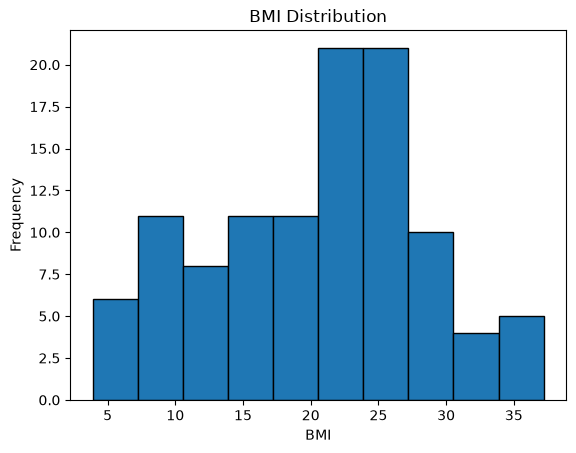

In [102]:
df['BMI'].plot(kind='hist', bins=10, edgecolor='black')
plt.xlabel('BMI')
plt.title('BMI Distribution')
plt.show()

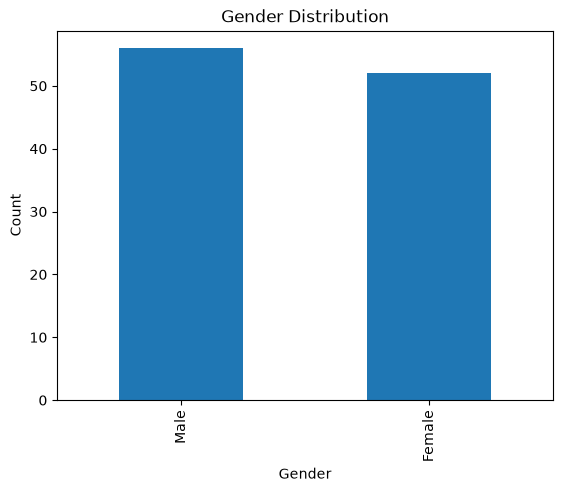

In [103]:
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

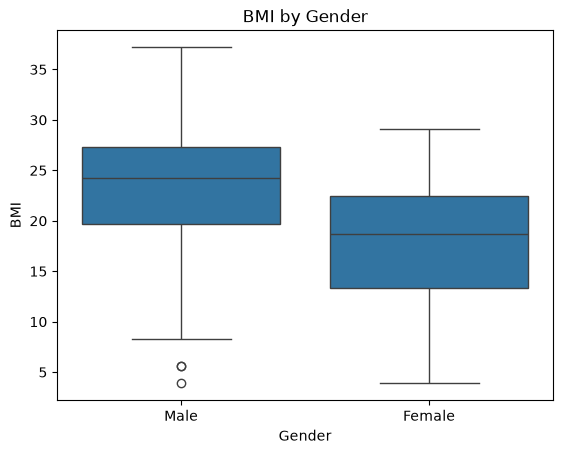

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Gender', y='BMI')

plt.title('BMI by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.show()

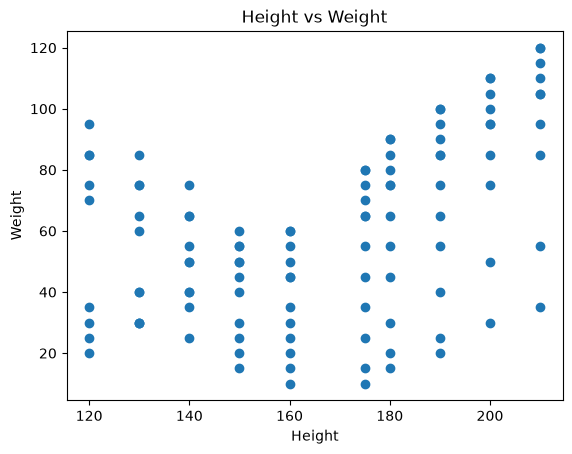

In [105]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

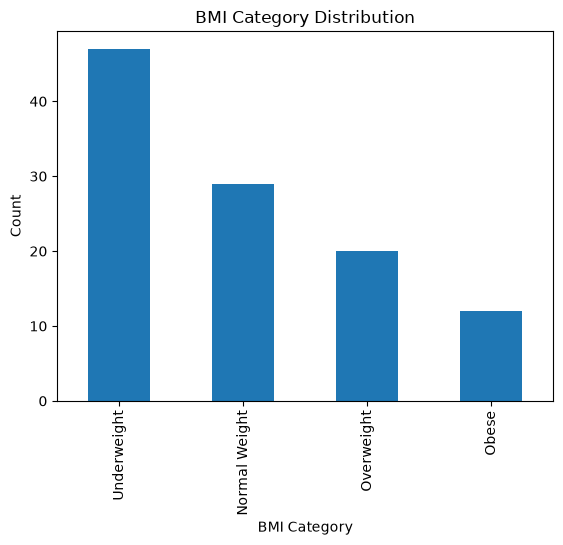

In [106]:
df['Label'].value_counts().plot(kind='bar')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.title('BMI Category Distribution')
plt.show()

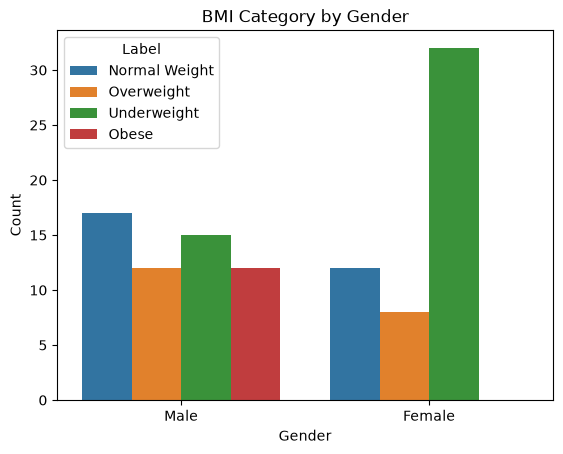

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Gender', hue='Label')

plt.title('BMI Category by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [108]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


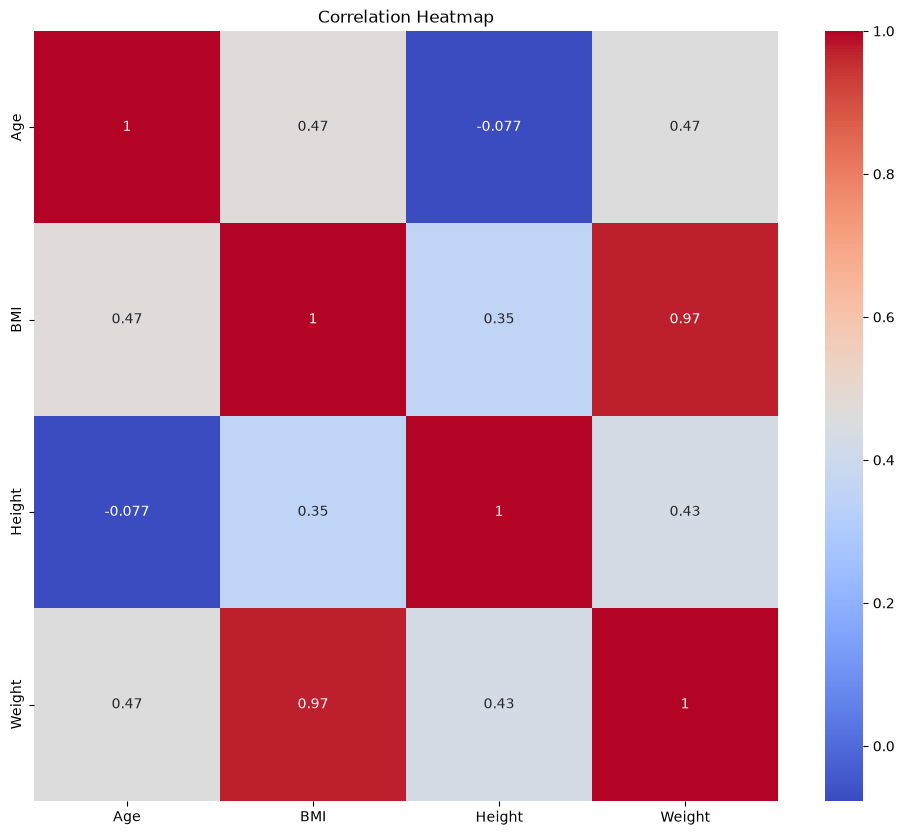

In [109]:
plt.figure(figsize=(12, 10))
num_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [110]:
target_col = "Label"  
corr_matrix = num_df.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.9:
            columns_to_drop.append(corr_matrix.columns[i])

print(columns_to_drop)

['Weight']


In [111]:
# df.drop("Weight", axis=1, inplace=True) # i dont drop it as i have less features for training the model

In [112]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


## Splitting the data for training

In [113]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 1)

In [114]:
df_train.head()

,Age,Gender,BMI,Height,Weight,Label
32,39,Male,27.0,190,95,Overweight
73,40,Female,20.0,140,50,Underweight
19,63,Female,13.3,120,30,Underweight
27,103,Female,13.3,130,30,Underweight
36,59,Male,30.8,210,115,Obese


In [115]:
df_test.head()

,Age,Gender,BMI,Height,Weight,Label
100,47,Female,13.3,130,30,Underweight
90,48,Female,16.7,130,40,Underweight
92,58,Female,16.7,120,35,Underweight
89,43,Male,20.0,200,50,Underweight
101,52,Male,16.7,210,35,Underweight


In [116]:
print("the shape of the train data set is : ", df_train.shape)
print("the shape of the test data set is : ", df_test.shape)

the shape of the train data set is :  (75, 6)
the shape of the test data set is :  (33, 6)


In [117]:
df_train.head()

,Age,Gender,BMI,Height,Weight,Label
32,39,Male,27.0,190,95,Overweight
73,40,Female,20.0,140,50,Underweight
19,63,Female,13.3,120,30,Underweight
27,103,Female,13.3,130,30,Underweight
36,59,Male,30.8,210,115,Obese


## Feature Encoding

In [118]:
nominal_cols = ['Gender']
label_col = ['Label']

### You can do this instead of using column transformers for small columns

In [119]:
df_train['Gender'] = (df_train['Gender'] == 'Male').astype(int)
df_test['Gender'] = (df_test['Gender'] == 'Male').astype(int)

In [120]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_train['Label'] = le.fit_transform(df_train['Label'])
df_test['Label'] = le.transform(df_test['Label'])

In [121]:
le.classes_

array(['Normal Weight', 'Obese', 'Overweight', 'Underweight'],
      dtype=object)

In [122]:
for i, label in enumerate(le.classes_):
    print(f"{i} -> {label}")

0 -> Normal Weight
1 -> Obese
2 -> Overweight
3 -> Underweight


In [123]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


## Feature Scaling

In [124]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_train[['BMI','Age','Height','Weight']] = scaler.fit_transform(df_train[['BMI','Age','Height','Weight']])
df_test[['BMI','Age','Height','Weight']] = scaler.transform(df_test[['BMI','Age','Height','Weight']])

In [125]:
df_train.head()

,Age,Gender,BMI,Height,Weight,Label
32,0.277228,1,0.693694,0.777778,0.772727,2
73,0.287129,0,0.483483,0.222222,0.363636,3
19,0.514851,0,0.282282,0.000000,0.181818,3
27,0.910891,0,0.282282,0.111111,0.181818,3
36,0.475248,1,0.807808,1.000000,0.954545,1


## Preparing the Input variable and Target Variable

In [126]:
y_train = df_train.pop('Label')
X_train = df_train

In [127]:
y_test = df_test.pop('Label')
X_test = df_test

In [128]:
X_train

,Age,Gender,BMI,Height,Weight
32,0.277228,1,0.693694,0.777778,0.772727
73,0.287129,0,0.483483,0.222222,0.363636
19,0.514851,0,0.282282,0.000000,0.181818
27,0.910891,0,0.282282,0.111111,0.181818
36,0.475248,1,0.807808,1.000000,0.954545
...,...,...,...,...,...
75,0.386139,0,0.558559,0.111111,0.454545
9,0.584158,0,0.183183,0.000000,0.090909
72,0.237624,1,0.564565,0.777778,0.500000
12,0.168317,1,0.642643,0.666667,0.636364


In [129]:
y_train

32    2
73    3
19    3
27    3
36    1
     ..
75    0
9     3
72    0
12    0
37    2
Name: Label, Length: 75, dtype: int64

In [130]:
# # Importing RFE and LogisticRegression
# from sklearn.feature_selection import RFE
# from sklearn.linear_model import LogisticRegression

# # Create model
# model = LogisticRegression()

# # Select top 5 features
# rfe = RFE(estimator=model, n_features_to_select=3)

# # Fit RFE
# X_rfe = rfe.fit_transform(X_train, y_train)

# # Selected feature names
# selected_features = X_train.columns[rfe.support_]

# print("Selected Features:")
# print(list(selected_features))

In [131]:
# feature_ranking = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Selected': rfe.support_,
#     'Rank': rfe.ranking_
# })

# feature_ranking.sort_values('Rank').reset_index(drop=True)

In [132]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [135]:
for i in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {i[0]}, Predicted: {i[1]}")

Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 2, Predicted: 2
Actual: 3, Predicted: 3
Actual: 2, Predicted: 1
Actual: 0, Predicted: 0
Actual: 2, Predicted: 1


In [136]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.73


## Accuracy Does Not Always Reflect the Real Performance of a Model

Let's say we have **100 students**:

- **90 students passed**
- **10 students failed**

Now suppose our model predicts that **every student passed**.

### Actual Results

| Actual | Count |
|----------|--------|
| Passed | 90 |
| Failed | 10 |

### Model Predictions

| Predicted | Count |
|------------|--------|
| Passed | 100 |
| Failed | 0 |

### Accuracy Calculation

Accuracy is calculated as:

Accuracy = Correct Predictions / Total Predictions

In this case:

Accuracy = 90 / 100 = 90%

So the model achieves **90% accuracy**.

### The Problem

Even though the accuracy is **90%**, the model completely fails to identify the **10 students who actually failed**.

This shows that a high accuracy score does not necessarily mean the model is performing well, especially when the dataset is **imbalanced**.

Because of this, we also use metrics such as:

- **Precision**
- **Recall**
- **F1 Score**

These metrics provide a more complete picture of the model's performance.

## Precision, Recall, and F1 Score

Continuing with the same example:

- 100 students in total
- 90 passed
- 10 failed

Let's assume **"Failed"**  as postive class. we are trying to check if that student fail or not

### Actual vs Predicted

|                | Predicted Failed | Predicted Passed |
|----------------|------------------|------------------|
| Actual Failed  | 8                | 2                |
| Actual Passed  | 5                | 85               |

### Understanding the Terms

- **True Positive (TP)** = 8  
  - Failed students correctly predicted as failed.

- **False Positive (FP)** = 5  
  - Passed students incorrectly predicted as failed.

- **False Negative (FN)** = 2  
  - Failed students incorrectly predicted as passed.

- **True Negative (TN)** = 85  
  - Passed students correctly predicted as passed.

---

## Precision

**Out of all students that our model predicted as failed, how many were actually failed?** <br>
**Hamro model le fail prediction gareko madhye kati chai real mai fail thiye?**

Formula:

Precision = TP / (TP + FP)

Calculation:

Precision = 8 / (8 + 5)

Precision = 8 / 13

Precision = 0.615 = 61.5%

### Intuition

Higher precision means fewer false alarms.

---

## Recall

**Out of all the actual failed students, how many were correctly identified as failed by our model?** <br>
**Vastav mai fail bhayeka students madhye, kati jana lai hamro model le fail bhani sahi predict garyo?**

Formula:

Recall = TP / (TP + FN)

Calculation:

Recall = 8 / (8 + 2)

Recall = 8 / 10

Recall = 0.8 = 80%

### Intuition

Recall measures how many actual failed students the model was able to catch.

Higher recall means fewer failed students are missed.

---

## F1 Score

Precision and Recall often trade off against each other.

The F1 Score combines both into a single metric.

Formula:

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

Calculation:

F1 Score = 2 × (0.615 × 0.8) / (0.615 + 0.8)

F1 Score = 0.695 = 69.5%

### Intuition

The F1 Score is high only when both Precision and Recall are high.

---

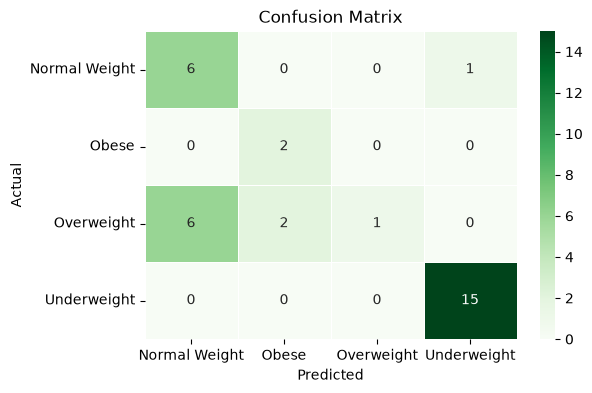

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = le.classes_
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [138]:
abels = le.classes_
abels

array(['Normal Weight', 'Obese', 'Overweight', 'Underweight'],
      dtype=object)

In [139]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.50      1.00      0.67         2
           2       1.00      0.11      0.20         9
           3       0.94      1.00      0.97        15

    accuracy                           0.73        33
   macro avg       0.73      0.74      0.62        33
weighted avg       0.84      0.73      0.67        33



## Normal Weight

### Recall = 0.86

Out of 7 people who were actually **Normal Weight**, the model correctly identified about **86%** of them.

### Precision = 0.50

Out of all people predicted as **Normal Weight**, only **50%** were actually Normal Weight.

### Interpretation

The model catches most Normal Weight people, but it also incorrectly labels many others as Normal Weight.

---

## Obese

### Recall = 1.00

Out of all actually **Obese** people, the model identified **every one of them**.

### Precision = 0.50

Out of all people predicted as **Obese**, only **50%** were actually Obese.

### Interpretation

The model doesn't miss Obese people, but it raises many false alarms.

---

## Overweight

### Recall = 0.11

Out of 9 actually **Overweight** people, the model identified only about **11%** of them.

### Precision = 1.00

Whenever the model predicts **Overweight**, it is always correct.

### Interpretation

The model is extremely conservative.

It predicts **Overweight** only when it is very confident, so:

- Almost no False Positives
- Lots of False Negatives

This is why Recall is very low.

---

## Underweight

### Recall = 1.00

The model identified **all Underweight people**.

### Precision = 0.94

Almost everyone predicted as **Underweight** was actually Underweight.

### Interpretation

This class is performing very well, with both high Precision and high Recall.

## Which Metric Should We Prioritize?

It depends on the goal of the system.

### If the goal is Health Screening

Prioritize **Recall** for the classes of interest (Overweight and Obese).

Why?

Because we do not want to miss people who may be overweight or obese.

Example:

- Person is actually Obese.
- Model predicts Normal Weight.

This person may not receive health advice or further screening.

In this case:

> Missing a risky patient is worse than raising a few extra alarms.

Therefore, Recall is important.

---

### If the goal is Providing Expensive Treatment or Programs

Prioritize **Precision**.

Example:

- Person is actually Normal Weight.
- Model predicts Obese.

The person may be unnecessarily enrolled in a costly health program.

In this case:

> False alarms are expensive.

Therefore, Precision is important.

---

### For BMI Classification

In most practical situations:

> Recall for Overweight and Obese classes is usually more important than Precision.

Because it is generally better to identify people who may be at health risk and then perform additional checks.

---

### Looking at Our Results

Overweight:

- Precision = 1.00
- Recall = 0.11

This means:

- When the model predicts Overweight, it is always correct.
- But it misses almost all Overweight people.

If this model were used for health screening, this would be a serious problem because many Overweight individuals would not be identified.

So in our case, improving Recall for the Overweight class would likely be more important than maintaining perfect Precision.

## Inference on the trained Model

In [55]:
import pandas as pd
import gradio as gr

def predict_obesity(age, gender, height, weight, bmi):
    gender_encoded = 1 if gender == "Male" else 0

    # Create input dataframe with same column order as training data
    input_df = pd.DataFrame({
        'Age': [age],
        'Gender': [gender_encoded],
        'Height': [height],
        'Weight': [weight],
        'BMI': [bmi]
    })

    # Reorder columns to match training data
    input_df = input_df[X_train.columns]

    # Scale features using the fitted scaler
    input_df[['BMI', 'Age', 'Height', 'Weight']] = scaler.transform(input_df[['BMI', 'Age', 'Height', 'Weight']])

    # Predict
    prediction = model.predict(input_df)

    # Map back to label name
    label = le.inverse_transform(prediction)[0]
    return f"Predicted Obesity Category: {label}"

gr.Interface(
    fn=predict_obesity,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(choices=["Male", "Female"], label="Gender"),
        gr.Number(label="Height (cm)"),
        gr.Number(label="Weight (kg)"),
        gr.Number(label="BMI"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Obesity Classification",
    flagging_mode="never"
).launch()

c:\z_Learn\miraj_pandas\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [68]:
df.head(1)

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight


In [56]:
for i, label in enumerate(le.classes_):
    print(f"{i} -> {label}")

0 -> Normal Weight
1 -> Obese
2 -> Overweight
3 -> Underweight


In [57]:
import pandas as pd

def predict_obesity(age, gender, height, weight, bmi):
    gender_encoded = 1 if gender == "Male" else 0

    # Create input dataframe with same column order as training data
    input_df = pd.DataFrame({
        'Age': [age],
        'Gender': [gender_encoded],
        'Height': [height],
        'Weight': [weight],
        'BMI': [bmi]
    })

    # Reorder columns to match training data
    input_df = input_df[X_train.columns]

    # Scale features using the fitted scaler
    input_df[['BMI', 'Age', 'Height', 'Weight']] = scaler.transform(input_df[['BMI', 'Age', 'Height', 'Weight']])

    # Predict
    prediction = model.predict(input_df)

    # Map back to label name
    label = le.inverse_transform(prediction)[0]
    return label

# Test prediction
result = predict_obesity(age=25, gender="Male", height=175, weight=80, bmi=26.1)
print(f"Predicted Obesity Category: {result}")

Predicted Obesity Category: Normal Weight
